# Task 05：Policy Gradient——学习与实验入口

## 本 Notebook 的学习边界

策略梯度直接优化 $\pi_	heta(a\mid s)$。REINFORCE 的单轨迹目标可写为：

$$

abla_	heta J(	heta)pprox\sum_t G_t
abla_	heta\log\pi_	heta(A_t\mid S_t).
$$

先理解 policy network 和采样，再运行 vanilla REINFORCE，随后加入 value baseline，最后用多个 seed 比较均值、方差和达到阈值所需 episode 数。


### Part D：多 seed 对照实验

# Task 05：Policy Gradient——学习与实验入口

## 本 Notebook 的学习边界

策略梯度直接优化 $\pi_	heta(a\mid s)$。REINFORCE 的单轨迹目标可写为：

$$

abla_	heta J(	heta)pprox\sum_t G_t
abla_	heta\log\pi_	heta(A_t\mid S_t).
$$

先理解 policy network 和采样，再运行 vanilla REINFORCE，随后加入 value baseline，最后用多个 seed 比较均值、方差和达到阈值所需 episode 数。


In [1]:
import sys
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append("../src")

from policy_network import PolicyNetwork
from reinforce import update_policy

from reinforce_baseline import (
    train_reinforce_baseline,
)
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

SEEDS = [0, 1, 2, 3, 4]

NUM_EPISODES = 1000

GAMMA = 0.99
LR = 1e-3
HIDDEN_DIM = 128

ENV_NAME = "CartPole-v1"

In [2]:
def train_vanilla_reinforce(
    seed,
    num_episodes=1000,
    gamma=0.99,
    lr=1e-3,
    hidden_dim=128,
):

    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(ENV_NAME)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=hidden_dim,
    )

    optimizer = torch.optim.Adam(
        policy.parameters(),
        lr=lr,
    )

    episode_returns = []

    for episode in range(num_episodes):

        if episode == 0:
            state, _ = env.reset(seed=seed)
        else:
            state, _ = env.reset()

        terminated = False
        truncated = False

        log_probs = []
        rewards = []

        while not (terminated or truncated):

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
            )

            action, log_prob = policy.sample_action(
                state_tensor
            )

            (
                next_state,
                reward,
                terminated,
                truncated,
                _,
            ) = env.step(
                action.item()
            )

            log_probs.append(log_prob)
            rewards.append(reward)

            state = next_state

        update_policy(
            optimizer=optimizer,
            log_probs=log_probs,
            rewards=rewards,
            gamma=gamma,
            normalize_returns=True,
        )

        episode_returns.append(
            sum(rewards)
        )

    env.close()

    return np.array(
        episode_returns,
        dtype=np.float32,
    )

In [3]:
vanilla_results = []
baseline_results = []


for seed in SEEDS:

    print(f"\n===== Seed {seed} =====")

    # --------------------------------------------------
    # Vanilla REINFORCE
    # --------------------------------------------------

    print("Training Vanilla REINFORCE...")

    vanilla_returns = train_vanilla_reinforce(
        seed=seed,
        num_episodes=NUM_EPISODES,
        gamma=GAMMA,
        lr=LR,
        hidden_dim=HIDDEN_DIM,
    )

    vanilla_results.append(
        vanilla_returns
    )

    # --------------------------------------------------
    # REINFORCE + Baseline
    # --------------------------------------------------

    print("Training REINFORCE + Baseline...")

    env = gym.make(ENV_NAME)

    (
        policy,
        value_net,
        history,
    ) = train_reinforce_baseline(
        env=env,
        num_episodes=NUM_EPISODES,
        gamma=GAMMA,
        policy_lr=LR,
        value_lr=LR,
        hidden_dim=HIDDEN_DIM,
        seed=seed,
        print_interval=1000,
    )

    baseline_returns = np.array(
        history["episode_returns"],
        dtype=np.float32,
    )

    baseline_results.append(
        baseline_returns
    )

    env.close()


vanilla_results = np.stack(
    vanilla_results
)

baseline_results = np.stack(
    baseline_results
)

print("\nVanilla shape:", vanilla_results.shape)
print("Baseline shape:", baseline_results.shape)


===== Seed 0 =====
Training Vanilla REINFORCE...
Training REINFORCE + Baseline...
Episode 1000 | Return  500.0 | Avg Return  401.54 | Policy Loss  -0.9414 | Value Loss 541.8023

===== Seed 1 =====
Training Vanilla REINFORCE...
Training REINFORCE + Baseline...
Episode 1000 | Return  500.0 | Avg Return  408.81 | Policy Loss  -2.2207 | Value Loss 529.6968

===== Seed 2 =====
Training Vanilla REINFORCE...
Training REINFORCE + Baseline...
Episode 1000 | Return  500.0 | Avg Return  408.12 | Policy Loss  -1.0373 | Value Loss 513.5489

===== Seed 3 =====
Training Vanilla REINFORCE...
Training REINFORCE + Baseline...
Episode 1000 | Return  500.0 | Avg Return  393.15 | Policy Loss  -5.1561 | Value Loss 503.0926

===== Seed 4 =====
Training Vanilla REINFORCE...
Training REINFORCE + Baseline...
Episode 1000 | Return  500.0 | Avg Return  381.12 | Policy Loss  -0.6627 | Value Loss 477.0287

Vanilla shape: (5, 1000)
Baseline shape: (5, 1000)


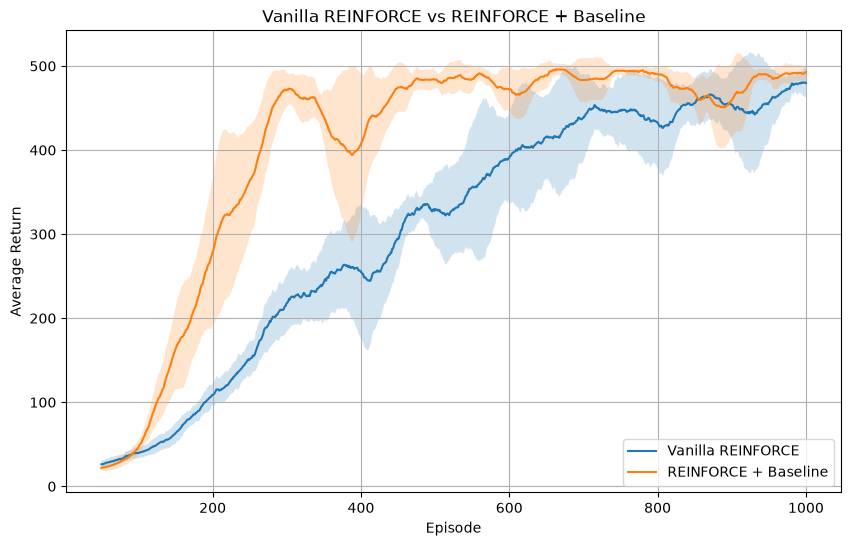

In [4]:
def moving_average(
    x,
    window=50,
):
    kernel = np.ones(window) / window

    return np.convolve(
        x,
        kernel,
        mode="valid",
    )


WINDOW = 50


vanilla_smoothed = np.stack([
    moving_average(
        run,
        WINDOW,
    )
    for run in vanilla_results
])

baseline_smoothed = np.stack([
    moving_average(
        run,
        WINDOW,
    )
    for run in baseline_results
])


vanilla_mean = vanilla_smoothed.mean(axis=0)
vanilla_std = vanilla_smoothed.std(axis=0)

baseline_mean = baseline_smoothed.mean(axis=0)
baseline_std = baseline_smoothed.std(axis=0)


episodes = np.arange(
    WINDOW,
    NUM_EPISODES + 1,
)


plt.figure(figsize=(10, 6))


# Vanilla

plt.plot(
    episodes,
    vanilla_mean,
    label="Vanilla REINFORCE",
)

plt.fill_between(
    episodes,
    vanilla_mean - vanilla_std,
    vanilla_mean + vanilla_std,
    alpha=0.2,
)


# Baseline

plt.plot(
    episodes,
    baseline_mean,
    label="REINFORCE + Baseline",
)

plt.fill_between(
    episodes,
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    alpha=0.2,
)


plt.xlabel("Episode")
plt.ylabel("Average Return")

plt.title(
    "Vanilla REINFORCE vs REINFORCE + Baseline"
)

plt.legend()
plt.grid()

plt.show()

In [5]:
FINAL_WINDOW = 100


vanilla_final = vanilla_results[
    :,
    -FINAL_WINDOW:
].mean(axis=1)

baseline_final = baseline_results[
    :,
    -FINAL_WINDOW:
].mean(axis=1)


print("===== Final 100-Episode Performance =====")

print(
    f"Vanilla REINFORCE: "
    f"{vanilla_final.mean():.2f} "
    f"± {vanilla_final.std():.2f}"
)

print(
    f"REINFORCE + Baseline: "
    f"{baseline_final.mean():.2f} "
    f"± {baseline_final.std():.2f}"
)

===== Final 100-Episode Performance =====
Vanilla REINFORCE: 468.12 ± 21.81
REINFORCE + Baseline: 490.41 ± 6.12


In [6]:
def episodes_to_threshold(
    returns,
    threshold=400,
    window=50,
):

    smoothed = moving_average(
        returns,
        window,
    )

    indices = np.where(
        smoothed >= threshold
    )[0]

    if len(indices) == 0:
        return np.nan

    return (
        indices[0]
        + window
    )


THRESHOLD = 400


vanilla_steps = np.array([
    episodes_to_threshold(
        run,
        threshold=THRESHOLD,
        window=WINDOW,
    )
    for run in vanilla_results
])


baseline_steps = np.array([
    episodes_to_threshold(
        run,
        threshold=THRESHOLD,
        window=WINDOW,
    )
    for run in baseline_results
])


print(
    f"Threshold = {THRESHOLD}"
)

print(
    "Vanilla:",
    vanilla_steps,
)

print(
    "Baseline:",
    baseline_steps,
)

print()

print(
    "Vanilla mean episodes:",
    np.nanmean(vanilla_steps),
)

print(
    "Baseline mean episodes:",
    np.nanmean(baseline_steps),
)

Threshold = 400
Vanilla: [613 522 553 558 500]
Baseline: [266 213 199 264 288]

Vanilla mean episodes: 549.2
Baseline mean episodes: 246.0


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
